# Applied Trading Strategies

## Trading Game: True Alpha or Fluke (probably fluke)


For each group, assume excess return of 0 and vol of 5% (the drawdown limit is 5% in the first 2 weeks and 7.5% in the last 3 weeks - Overall, I'm assuming the annualised vol is 7% to simplify -- vol and DD are not the same!)
We have 12 groups (including the group of the instructor/TA) trading for 5 weeks. How can we determine if a group ends up with a significant P&L that it's due to skill/alpha and not pure luck?

Suggest something like the below. Or come up with your own approach:  
For each group, assume excess return of 0 and vol of 7.5% (the drawdown limit is 5% in the first 2 weeks and 7.5% in the last 3 weeks - I'm assuming the ann. vol is 7.5% to simplify -- vol and DD are not the same)  
  
Step 1 - Run MC simulations with N ~ (0, 7.5%) - in each sim, run 12 x 5-week performances  
Step 2 - For each sim, pick out the return of the best (the max)  
Step 3 - Run another set of MC simulations with each sim using the distribution of the max from Step 1 - same return and vol.  
This should give a return distribution of the max of the 12 groups assuming zero alpha.  
Step 4 - Compare the max P&L of the 12 groups over the 5 weeks vs. the distribution in Step 3 using a hypothesis test to determine (best guess)if that P&L is due to alpha or luck.  
Step 5 - Additionally, maybe compare the 1/n portfolio of all 12 groups (an implicit fund of funds or an equal-weighted multi-strat fund) vs the distribution in Step 1 - Goal is to quantify x% probability that the whole class has a Sharpe Ratio of > 0.  
  
Attached is the JPM paper "Androids" for short, that we briefly discuss in class. Exhibit 4 (Page 5) may give you more ideas - it gives a distribution of Sharpe Ratios and with a vertical slice/cross section taken to figure out if a high realised SR is due to luck or skill.

In [2]:
# importing required libraries
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Step 0 - setting up stuff

ann_vol  = 0.075 # assumed annual volatility of 7.5%
n_groups = 12 # 12 groups
n_weeks = 5 # trading game over 5 weeks
n_sims = 1000 # number of MC simulations to run

# Converting annual volatility to 5-week volatility
'''
5_week_volatility = annual_volatility * sqrt(5 / 52)
'''
vol_5w = ann_vol * np.sqrt(n_weeks / 52)
print(f'5-week volatility: {vol_5w:.4f}')

5-week volatility: 0.0233


95th percentile of lucky winner (need to exceed to be lucky): 3.81%
99th percentile of lucky winner (need to exceed to be very lucky): 5.41%


TypeError: vlines() missing 2 required positional arguments: 'ymin' and 'ymax'

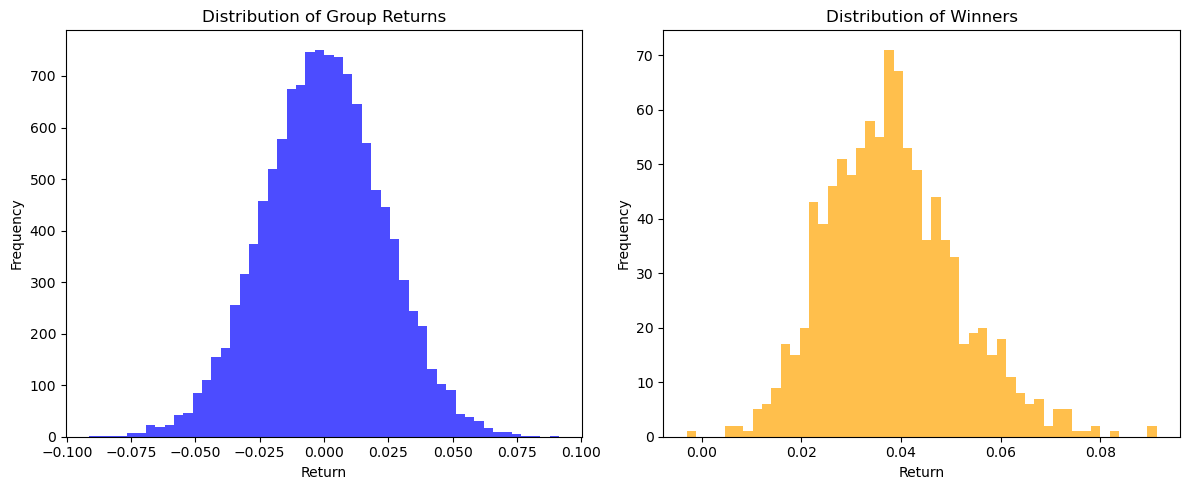

In [ ]:
# Step 1 - null distribution of winners

np.random.seed(42)
returns = np.random.normal(loc=0, scale=vol_5w, size=(n_sims, n_groups)) #assuming 0 alpha

# from each simulation, find the winner (max return)
winners = returns.max(axis=1)

# thresholds for winners (1 and 5%)
p95 = np.percentile(returns, 95)
p99 = np.percentile(returns, 99)

print(f"95th percentile of lucky winner (need to exceed to be lucky): {p95:.2%}")
print(f"99th percentile of lucky winner (need to exceed to be very lucky): {p99:.2%}")

#plot graphs of normal distribution of returns and winners
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(returns.flatten(), bins=50, alpha=0.7, color='blue')
plt.title('Distribution of Group Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
plt.hist(winners, bins=50, alpha=0.7, color='orange')
plt.title('Distribution of Winners')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.vlines(p95, color='red', linestyle='dashed', linewidth=2, label='95th Percentile')
# Step 1 - null distribution of winners

np.random.seed(42)
returns = np.random.normal(loc=0, scale=vol_5w, size=(n_sims, n_groups))  # assuming 0 alpha

# from each simulation, find the winner (max return)
winners = returns.max(axis=1)

# thresholds for winners (1 and 5%)
p95 = np.percentile(winners, 95)
p99 = np.percentile(winners, 99)

print(f"95th percentile of lucky winner (need to exceed to be lucky): {p95:.2%}")
print(f"99th percentile of lucky winner (need to exceed to be very lucky): {p99:.2%}")

# plot graphs of normal distribution of returns and winners
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(returns.flatten(), bins=50, alpha=0.7, color='blue')
plt.title('Distribution of Group Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(winners, bins=50, alpha=0.7, color='orange')
plt.title('Distribution of Winners')
plt.xlabel('Return')
plt.ylabel('Frequency')

plt.tight_layout()
plt.axvline(p95, color='red', linestyle='dashed', linewidth=2, label='95th Percentile')
plt.axvline(p99, color='green', linestyle='dashed', linewidth=2, label='99th Percentile')
plt.legend()
plt.show()
plt.show()
